# FEATURE ENGINEERING

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_excel("../data/clean_fashion_brands.xlsx")

In [3]:
df.head()

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Collaboration_Score
0,Nike,Sportswear,USA,27,1.90,166,High,Young Adults,3549,83,9,NaN
1,Adidas,Sportswear,Germany,60,2.63,98,Medium,Adults,4118,86,19,NaN
2,Puma,Sportswear,Germany,79,2.86,88,Medium,Young Adults,1217,75,13,NaN
3,Zara,Fast Fashion,Spain,22,1.35,46,High,Adults,681,84,12,NaN
4,H&M,Fast Fashion,Sweden,15,1.72,65,High,Adults,2386,92,6,NaN


In [4]:
df.dtypes

Brand                   object
Category                object
Country                 object
Followers_Million        int64
Engagement_Rate        float64
Avg_Price_USD            int64
Sustainability          object
Target_Audience         object
Global_Stores            int64
Trend_Score              int64
Collaboration_Count      int64
Collaboration_Score    float64
dtype: object

In [5]:
sustainability_map = {
    "Low":1,
    "Medium":2,
    "High":3
}

df["Sustainability_Score"] = df["Sustainability"].map(sustainability_map)

In [6]:
df[["Sustainability","Sustainability_Score"]].head()

,Sustainability,Sustainability_Score
0,High,3
1,Medium,2
2,Medium,2
3,High,3
4,High,3


In [7]:
audience_encoder = LabelEncoder()

df["Audience_Code"] = audience_encoder.fit_transform(df["Target_Audience"])

In [8]:
df[["Target_Audience","Audience_Code"]].head()

,Target_Audience,Audience_Code
0,Young Adults,2
1,Adults,0
2,Young Adults,2
3,Adults,0
4,Adults,0


In [9]:
features = [
    "Followers_Million",
    "Engagement_Rate",
    "Avg_Price_USD",
    "Global_Stores",
    "Trend_Score",
    "Collaboration_Count",
    "Sustainability_Score"
]

In [10]:
scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

In [11]:
df.head()

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Collaboration_Score,Sustainability_Score,Audience_Code
0,Nike,Sportswear,USA,0.076923,0.391061,0.070041,High,Young Adults,0.726677,0.464286,0.272727,NaN,1.0,2
1,Adidas,Sportswear,Germany,0.182692,0.798883,0.035276,Medium,Adults,0.847049,0.571429,0.727273,NaN,0.5,0
2,Puma,Sportswear,Germany,0.243590,0.927374,0.030164,Medium,Young Adults,0.233340,0.178571,0.454545,NaN,0.5,2
3,Zara,Fast Fashion,Spain,0.060897,0.083799,0.008691,High,Adults,0.119949,0.500000,0.409091,NaN,1.0,0
4,H&M,Fast Fashion,Sweden,0.038462,0.290503,0.018405,High,Adults,0.480643,0.785714,0.136364,NaN,1.0,0


In [12]:
df["Collaboration_Score"] = (
      df["Followers_Million"] * 0.25
    + df["Engagement_Rate"] * 0.20
    + df["Trend_Score"] * 0.25
    + df["Sustainability_Score"] * 0.10
    + df["Collaboration_Count"] * 0.10
    + df["Global_Stores"] * 0.10
)

In [17]:
df["Collaboration_Score"] = df["Collaboration_Score"].round(2)

In [18]:
df.sort_values(
    by="Collaboration_Score",
    ascending=False
).head(10)

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Collaboration_Score,Sustainability_Score,Audience_Code
62,Lululemon,Sportswear,Canada,0.964744,0.508380,0.034254,High,Adults,0.360694,0.750000,0.818182,74.82,1.0,0
5,Uniqlo,Casual,Japan,0.057692,0.932961,0.030164,High,Young Adults,0.768564,1.000000,0.500000,67.79,1.0,2
64,Decathlon,Sportswear,France,0.605769,0.938547,0.057260,Low,Adults,0.782526,0.928571,0.045455,65.41,0.0,0
66,Massimo Dutti,Premium,Spain,0.400641,0.407821,0.029141,High,Young Adults,0.505395,0.928571,0.818182,64.62,1.0,2
92,Ted Baker,Premium,UK,0.955128,0.229050,0.026074,Low,Young Adults,0.524646,0.892857,0.727273,63.30,0.0,2
82,Alo Yoga,Sportswear,USA,0.387821,0.614525,0.043967,Low,Young Adults,0.704887,1.000000,0.863636,62.67,0.0,2
38,Reebok,Sportswear,USA,0.375000,0.726257,0.068507,Medium,Teens,1.000000,0.785714,0.272727,61.27,0.5,1
17,Calvin Klein,Premium,USA,0.974359,0.418994,0.038344,Medium,Teens,0.512799,0.571429,0.363636,60.79,0.5,1
80,Jack Wolfskin,Outdoor,Germany,0.083333,0.670391,0.027607,High,Young Adults,0.437275,0.785714,1.000000,59.51,1.0,2
19,Lacoste,Premium,France,0.663462,0.530726,0.026585,Medium,Teens,0.885340,0.607143,0.318182,59.41,0.5,1


In [20]:
# Remove incorrect score
df.drop(columns=["Collaboration_Score"], inplace=True, errors="ignore")

In [21]:
df["Collaboration_Score"] = (
      df["Followers_Million"] * 0.25
    + df["Engagement_Rate"] * 0.20
    + df["Trend_Score"] * 0.25
    + df["Sustainability_Score"] * 0.10
    + df["Collaboration_Count"] * 0.10
    + df["Global_Stores"] * 0.10
)

In [22]:
df["Collaboration_Score"] = df["Collaboration_Score"].round(2)

In [23]:
df.sort_values(
    by="Collaboration_Score",
    ascending=False
).head(10)

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Sustainability_Score,Audience_Code,Collaboration_Score
62,Lululemon,Sportswear,Canada,0.964744,0.508380,0.034254,High,Adults,0.360694,0.750000,0.818182,1.0,0,0.75
5,Uniqlo,Casual,Japan,0.057692,0.932961,0.030164,High,Young Adults,0.768564,1.000000,0.500000,1.0,2,0.68
64,Decathlon,Sportswear,France,0.605769,0.938547,0.057260,Low,Adults,0.782526,0.928571,0.045455,0.0,0,0.65
66,Massimo Dutti,Premium,Spain,0.400641,0.407821,0.029141,High,Young Adults,0.505395,0.928571,0.818182,1.0,2,0.65
82,Alo Yoga,Sportswear,USA,0.387821,0.614525,0.043967,Low,Young Adults,0.704887,1.000000,0.863636,0.0,2,0.63
92,Ted Baker,Premium,UK,0.955128,0.229050,0.026074,Low,Young Adults,0.524646,0.892857,0.727273,0.0,2,0.63
38,Reebok,Sportswear,USA,0.375000,0.726257,0.068507,Medium,Teens,1.000000,0.785714,0.272727,0.5,1,0.61
17,Calvin Klein,Premium,USA,0.974359,0.418994,0.038344,Medium,Teens,0.512799,0.571429,0.363636,0.5,1,0.61
80,Jack Wolfskin,Outdoor,Germany,0.083333,0.670391,0.027607,High,Young Adults,0.437275,0.785714,1.000000,1.0,2,0.60
19,Lacoste,Premium,France,0.663462,0.530726,0.026585,Medium,Teens,0.885340,0.607143,0.318182,0.5,1,0.59


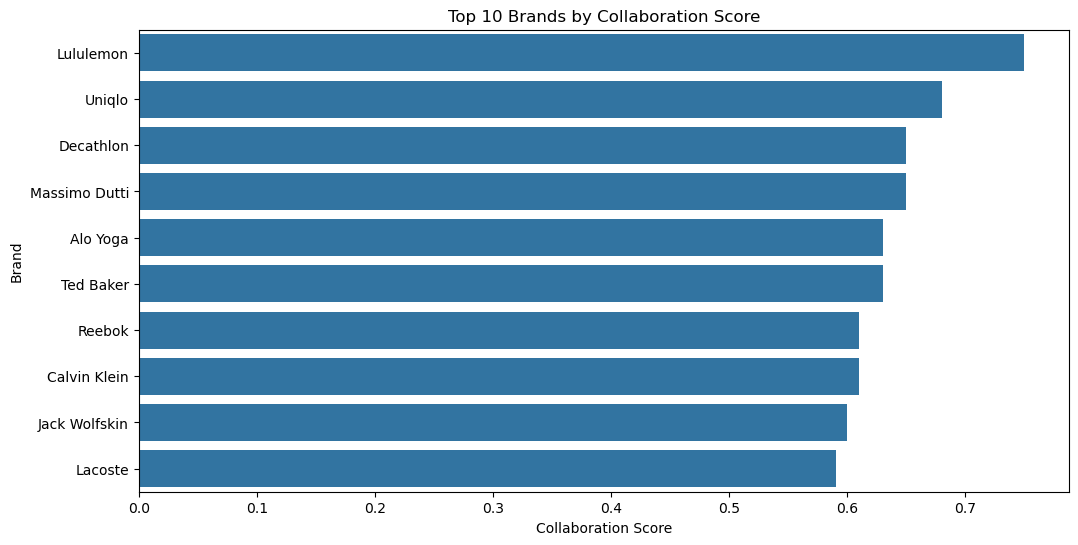

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = df.sort_values(
    by="Collaboration_Score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Collaboration_Score",
    y="Brand"
)

plt.title("Top 10 Brands by Collaboration Score")
plt.xlabel("Collaboration Score")
plt.ylabel("Brand")

plt.show()

## Business Insight

The Collaboration Score combines social media presence, engagement, trend score, sustainability, global reach, and previous collaborations.

Brands with higher scores are stronger candidates for strategic collaborations because they have greater visibility, influence, and market presence.